<h1><center>🧠 Homework №1 — BERT for Aspect-Based Sentiment Classification

*Natural Language Processing Course, HSE 2026*

This homework is designed as a hands-on, research-style assignment. You
are expected not only to train models, but also to make methodological
decisions, justify them, and analyze results critically (*this will be taken into account when grading your assignment*) — like an ML
engineer or NLP researcher.

This homework **is based on the materials from the Webinar 2** - take a look at the notebook from that class as it might be really helpful when completing this assignment.

<p align="center">
  <img src="https://www.philschmid.de/static/blog/bert-text-classification-in-a-different-language/meme.png" width="60%">
</p>

### 📥 General Rules and Submission Guidelines

1. Copying code from external sources (**including using LLMs**) without explicit citation is strictly prohibited and will result in 0 points for the entire assignment. If you consult any resources or AI tools, you must clearly state this in a separate Markdown cell. If suspected of this, you might be asked to explain your code to the grader and answer their questions during a separate session to avoid the mentioned penalty.
2. All results must be fully **reproducible**. You are required to use `set_seed` everywhere so that the grader can obtain the same results when rerunning your notebook.
3. The notebook must run from top to bottom without errors. Submissions that fail to execute sequentially will not be accepted.
4. You must satisfy all requirements in each task to receive full credit. Partial completion may lead to partial scoring.
5. Do not modify the original notebook structure or provided Markdown cells. You are only allowed to write code in the sections marked `# TODO: your code here`. Any explanations, interpretations, or additional comments must be placed **in separate Markdown cells**. If you choose to do so, leave an explanation as to what and why was changed.
6. The final submission must be a completed `.ipynb` Jupyter Notebook. You may conduct your experiments in Jupyter Notebook, VS Code, or Google Colab — whichever environment you prefer.

### 🎯 Learning Objectives

By completing this homework, you will:
- Work with a realistic, noisy text dataset.
- Perform careful data preprocessing and label engineering.
- Fine-tune multiple encoder-based transformer models.
- Use validation loss for model selection (early stopping).
- Conduct basic hyperparameter tuning.
- Log your results.
- Build ablation tables and compare experimental settings.
- Interpret results obtained through conducted experiments.

Without any further ado, let's get started. Good luck, and may the odds be ever in your favor!

### 🔧 Environment Setup

Loading necessary libraries. If you need anything else, feel free to add more libraries and dependencies.

In [1]:
! pip install transformers[torch] datasets evaluate optuna -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorWithPadding
)

from datasets import Dataset
import evaluate
import optuna
import random


# TODO: your code here
import seaborn as sns
from datasets import DatasetDict, ClassLabel

In [3]:
if not torch.cuda.is_available():
    print("Warning: training will be slow without GPU!")

In [4]:
def set_seed(seed):
    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(1337)

### 🗂️ **Part №1. Data Preparation. ($1$ point)**

In this assignment, we're going to be work with the dataset containing reviews on restaurants. The dataset can be downloaded from [here](https://drive.google.com/file/d/19qXNsW-gc_H4ufAt0JREzszKzjKkh170/view).

In this part of the assignment, you will prepare the raw restaurant reviews dataset for model training. The goal is to obtain clean text data, a well-defined target variable, and reproducible train/validation/test splits.

**1.1. Loading and inspecting data ($0.25$ points)**

First, create a code cell that:
- loads the .jsonl file,
- prints basic statistics (size, columns, example rows),
- briefly comments on what you see.

In [5]:
!wget -O restaurants_reviews.jsonl \
"https://drive.google.com/uc?export=download&id=1EtlYDa05wGaF_6kqdb08XbKMRTliSlrT"

--2026-02-19 15:01:00--  https://drive.google.com/uc?export=download&id=1EtlYDa05wGaF_6kqdb08XbKMRTliSlrT
Распознаётся drive.google.com (drive.google.com)… 64.233.165.194, 2a00:1450:4010:c0f::c2
Подключение к drive.google.com (drive.google.com)|64.233.165.194|:443... соединение установлено.
HTTP-запрос отправлен. Ожидание ответа… 303 See Other
Адрес: https://drive.usercontent.google.com/download?id=1EtlYDa05wGaF_6kqdb08XbKMRTliSlrT&export=download [переход]
--2026-02-19 15:01:00--  https://drive.usercontent.google.com/download?id=1EtlYDa05wGaF_6kqdb08XbKMRTliSlrT&export=download
Распознаётся drive.usercontent.google.com (drive.usercontent.google.com)… 142.251.1.132, 2a00:1450:4010:c1e::84
Подключение к drive.usercontent.google.com (drive.usercontent.google.com)|142.251.1.132|:443... соединение установлено.
HTTP-запрос отправлен. Ожидание ответа… 200 OK
Длина: 80131991 (76M) [application/octet-stream]
Сохранение в: ‘restaurants_reviews.jsonl’

restaurants_reviews 100%[==================

In [6]:
# TODO: load jsonl into a DataFrame
df = pd.read_json('restaurants_reviews.jsonl', lines=True)
df.head(3)

,review_id,general,food,interior,service,text
0,0,0,10,10,10,Вытянули меня сегодня в город и раз уж была в ...
1,1,0,9,10,9,проводили корпоратив на 60 чел. в этот - уже т...
2,2,0,9,10,10,Был в Гостях с женой один раз и еще раз с жено...


In [7]:
# TODO: print out statistics and add your comments as an md cell (what we're seeing, any trends - whatever seems relevant to the observed stats)
print(df.info())
print()
print(df.describe(include='all'))
print()
print(df.nunique())
print()

for col_name in ['general', 'food', 'interior', 'service']:
    print(df[col_name].value_counts())
    print()

print(f'text length', df['text'].apply(len).describe(), sep='\n')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47139 entries, 0 to 47138
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review_id  47139 non-null  int64 
 1   general    47139 non-null  int64 
 2   food       47139 non-null  object
 3   interior   47139 non-null  object
 4   service    47139 non-null  object
 5   text       47139 non-null  object
dtypes: int64(2), object(4)
memory usage: 2.2+ MB
None

           review_id       general     food  interior  service  \
count   47139.000000  47139.000000  47139.0   47139.0  47139.0   
unique           NaN           NaN     12.0      12.0     12.0   
top              NaN           NaN      0.0       0.0      0.0   
freq             NaN           NaN  13948.0   13948.0  13948.0   
mean    23569.000000      0.277732      NaN       NaN      NaN   
std     13608.001506      1.100144      NaN       NaN      NaN   
min         0.000000      0.000000      NaN       NaN      NaN

В столбцах food, interior и service представлены оценки от 0 до 10, но также присутствуют пропуски, замененные на -. В столбце general представлены оценки от 0 до 5. Тексты из датасета имеют длину от 3 до 24228 символов, но в среднем состоят из 912 символов, также видно, что присутствуют выбросы по длине текста

**1.2 Target variable selection and cleaning ($0.25$ points)**

#### 📚 Quick Dataset Overview

As you have probably already guessed, you will work with a dataset of Russian restaurant reviews stored in restaurants_reviews.jsonl. Each row corresponds to one user review and includes:

- review_id — unique identifier of the review  
- text — the review text (input to the model)  
- food — rating of food quality  
- service — rating of service quality  
- interior — rating of interior/atmosphere  
- general — overall rating (summary score)

The key idea is that the dataset provides aspect-based ratings: the same review can express different opinions about food, service, and interior. For example, a review might praise the food but criticize the service. This makes the task more realistic than standard “overall sentiment” classification.

Now, your task is to choose ONE aspect as the target variable for sentiment classification:

- ✅ food  
- ✅ service  
- ✅ interior  
- ❌ general cannot be used as a target label in this homework.

After that,
- Once you've picked your target - keep only 2 columns (target variable - name it "`food/interior/service_score`"  and `text`). You will not need id or other aspects (the ones you did NOT choose) for the training process, so we'll remove them for convenience.
- After selecting your target aspect, remove all samples where the corresponding rating equals $0$.  
In this dataset, a score of $0$ indicates that the reviewer **did not provide a rating for this aspect**, so such reviews should not be included in further analysis.
- Explain in a Markdown comment why the previous step is necessary (removal of $0$-scored reviews).

The result of this task is a df with 2 columns, e.g. "interior_score", "text" with no missing values.

In [8]:
# TODO: your code here
df = df[['food', 'text']]

In [9]:
# TODO: your code here
df = df[~df['food'].isin([0, '-'])]# также надо удалить строки со значением -, так как это тоже пропуски

In [10]:
# TODO: your code here

Необходимо удалить строки, в которых оценка еды равна 0 и - (хотя этого не сказано в задании), потому что в соответствующих комментариях может не присутствовать информация о еде или присутствовать вообще любая информация о еде (положительная и отрицательная). Такие строки необходимо удалить для устранения неоднозначности # TODO: your code here

**1.3 Label binning into 3 classes ($0.25$ points)**

At this point, you have a dataset that contains raw scores for your chosen aspect in the range 1–10 (after removing missing values).

Your goal in this section is to reduce this 10-point scale to three sentiment classes:

 - $0$ → BAD
 - $1$ → NEUTRAL
 - $2$ → GOOD

Before creating these classes, you must first visualize the original rating distribution so that your binning strategy is data-driven rather than arbitrary.
In the next cell, plot the distribution of the raw ratings using either:
 - a histogram, or
 - a bar/count plot.

/tmp/ipykernel_348237/3710766687.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="food", order=range(1, 11), palette="viridis")


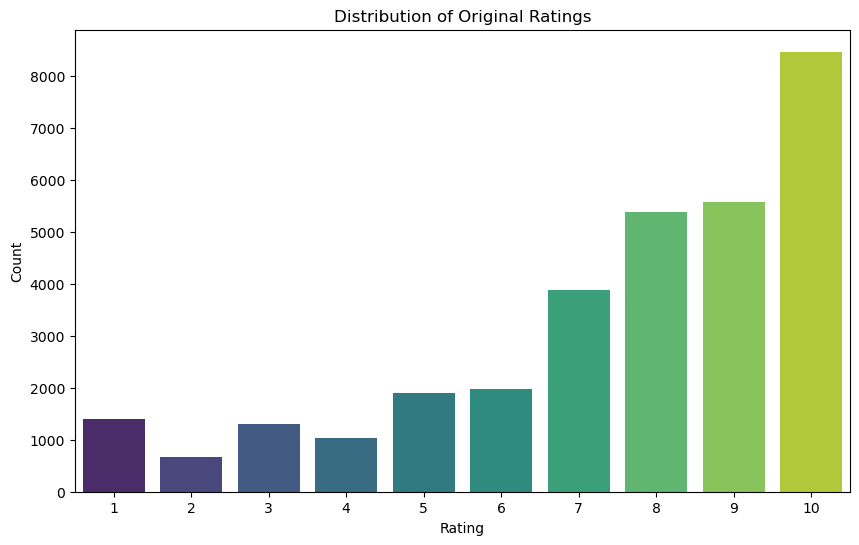

In [11]:
# TODO: visualize distribution

plt.figure(figsize=(10, 6))

# TODO: replace ___ with correct parameters
sns.countplot(data=df, x="food", order=range(1, 11), palette="viridis")

plt.title("Distribution of Original Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

After inspecting the plot, add a Markdown explanation describing how and why you have decided to map the 1–10 scale into three groups.

**Your explanation here:** разделим оценки таким образом, чтобы примерно одинаковое количество оценок попало в каждую группу: 

* BAD: от 1 до 7 (примерно 12к)
* NEUTRAL: от 8 до 9 (примерно 11к)
* GOOD: 10 (примерно 8к)

Now, implement your mapping in code into three sentiment classes: BAD ($0$), NEUTRAL ($1$), and GOOD ($2$). Your mapping must produce labels in {$0$, $1$, $2$}.

In [12]:
# TODO: mapping
def bin_label(rating):
    rating = int(rating)
    if rating in [1, 2, 3, 4, 5, 6, 7]:
        return 0
    elif rating in [8, 9]:
        return 1
    elif rating in [10]:
        return 2
    else:
        raise Exception('Bad rating')

In [13]:
# TODO: print out results
df['food_formatted'] = df['food'].apply(bin_label) # исходный столбец food пригодится потом
df

,food,text,food_formatted
0,10,Вытянули меня сегодня в город и раз уж была в ...,2
1,9,проводили корпоратив на 60 чел. в этот - уже т...,1
2,9,Был в Гостях с женой один раз и еще раз с жено...,1
4,7,В « Bel Canto » мы отмечали юбилей моего отца ...,0
5,10,"Здравствуйте , уважаемые женихи и невесты . Г...",2
...,...,...,...
33186,5,Безусловно благодарен сотрудникам ресторана за...,0
33187,9,Полностью согласна с предыдущим отзывом . Дей...,1
33188,8,Вот и добрались до Богарт'с . Как всегда - бу...,1
33189,7,"Дело было не так давно , собрались мы в театр ...",0


**1.4. Formatting ($0.25$ points)**

At this point in the pipeline, we already have:
- a cleaned dataset of reviews, and
- their corresponding sentiment labels in {0, 1, 2}.

However, our data is still stored in a pandas DataFrame, which is not the native format expected by the Hugging Face training ecosystem.

**Task:** to make our data compatible with the Trainer API and other transformer utilities, you need to
- convert it into a datasets.Dataset object
- perform train/val/test split. The proprotions are 70/15/15

In [14]:
# TODO: your code here
data = Dataset.from_dict({'text': df['text'], 'label': df['food_formatted']})
data = data.cast_column("label", ClassLabel(num_classes=3))# иначе не работает стратификация

Casting the dataset:   0%|          | 0/31607 [00:00<?, ? examples/s]

In [15]:
# TODO: your code here
train_test_sp = data.train_test_split(test_size=0.15, shuffle=True, seed=1337, stratify_by_column='label')
train_data = train_test_sp['train']
test_data = train_test_sp['test']

train_val_sp = train_data.train_test_split(test_size=0.176, shuffle=True, seed=1337, stratify_by_column='label')
train_data = train_test_sp['train']
val_data = train_test_sp['test']

print(train_data.num_rows/data.num_rows, val_data.num_rows/data.num_rows, test_data.num_rows/data.num_rows)

data = DatasetDict({
    "train": train_data,
    "val": val_data,
    "test": test_data,
})

0.8499699433669756 0.15003005663302432 0.15003005663302432


In [16]:
data

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 26865
    })
    val: Dataset({
        features: ['text', 'label'],
        num_rows: 4742
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 4742
    })
})

### 💻 **Transition Part ($1$ ⏩ $2$). From text to tensors. ($0.5$ points)**

Some theory for a better understanding of **why** (*but why?*... 🐧) we're doing **what** we're doing:

At this stage of the pipeline, we already have clean texts and well-defined labels in the right format, but transformer models cannot operate directly on raw strings. They require numerical representations that reflect how each specific model was trained. This is why we perform tokenization before training.

It is important to emphasize that tokenization is model-dependent. Different pretrained models were trained on different corpora and use different vocabularies, token boundaries, and subword segmentation rules. As a result, the same sentence may be split into different tokens by different models, even though the underlying meaning is identical. This is why we cannot tokenize the data once and reuse it for all models.

**In this assignment, the tokenization step must be repeated separately for each model.**

For each model separately, you will:
 1. Load the model-specific tokenizer from Hugging Face.
 2. Tokenize all three splits (train, val, test) of the Dataset object.
 3. Wrap the tokenized outputs and labels into a DataLoader, creating 3 separate dataloader objects.

Only after this step will you proceed to fine-tuning.


As our first model, let us take [ruBert-base](https://huggingface.co/sberbank-ai/ruBert-base/). Perform tokenization in the following cells.

In [17]:
# TODO: perform data tokenization
base_model = 'ai-forever/ruBert-base'
tokenizer = AutoTokenizer.from_pretrained(base_model)
data_tokenized = data.map(lambda x: tokenizer(x['text'], truncation=True, padding='max_length', max_length=512, return_tensors='pt'), batched=True, remove_columns=['text'])

data_tokenized

Map:   0%|          | 0/26865 [00:00<?, ? examples/s]

Map:   0%|          | 0/4742 [00:00<?, ? examples/s]

Map:   0%|          | 0/4742 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 26865
    })
    val: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 4742
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 4742
    })
})

Wrap the tokenized data into a DataLoader

In [18]:
# TODO: collator initialization and wrapping
collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [19]:
train_dataloader = DataLoader(data_tokenized['train'], shuffle=True, batch_size=4, collate_fn=collator)
val_dataloader = DataLoader(data_tokenized['val'], shuffle=False, batch_size=4, collate_fn=collator)
test_dataloader = DataLoader(data_tokenized['test'], shuffle=False, batch_size=4, collate_fn=collator)

**What you enter Part 2 with:**

At the start of Part 2, you should have:
1. 3 Dataloader objects
2. All of them must be tokenized (you will later need to change it, depending on what model you are training),

### 💪 **Part 2. Fine-tuning. ($3$ points)**

In this part of the assignment, you will complete the following stages:
 1. **Baseline model.**
Train a baseline encoder model on the prepared dataset. This establishes a reference point for all future comparisons. ($1$ point)
 2. **Model comparison (3 encoders total).**
Train two additional encoder models under the same data split and evaluation protocol. Compare results across all three models and choose the most promising model to continue working with. ($2$ points)

Training must be stopped automatically via early stopping: once the quality metric stops improving (i.e., reaches a plateau), training should terminate and the best checkpoint must be selected. Do not forget that data is shared across all models (do not redo the split), but **tokenization is model-specific**.

#### Models to choose from:
1. [ruBert-base](https://huggingface.co/sberbank-ai/ruBert-base/)  
2. [ruBert-large](https://huggingface.co/sberbank-ai/ruBert-large/)
3. [ruBert-tiny](https://huggingface.co/cointegrated/rubert-tiny2)
4. [mBert](https://huggingface.co/google-bert/bert-base-multilingual-cased)

More documentation: [`transformers`](https://huggingface.co/docs/transformers/index)


Throughout this assignment, the primary metric is `accuracy` (multiclass classification).
Before training any model, you must implement a function that computes accuracy from model predictions. In the next section, you will define this metric function and integrate it into your training loop.

In [20]:
def compute_metrics(eval_pred):
    """ Func for calculating accuracy
    (The primary metric must be accuracy. You may optionally add others) """

    logits, labels = eval_pred # TODO
    preds = np.argmax(logits, axis=-1)
    return {'accuracy': np.mean(preds == labels)} # TODO

Next, choose a model (overall you need to conduct initial experiments with 3 of them). In the initial task, we already used a tokenizer for ruBert-base, so you might want to proceed with that first.

In [21]:
# TODO: load a pretrained encoder
model_name = base_model

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ai-forever/ruBert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Thanks to a user-friendly interface of training, a developer can focus on high-level tasks (rather than implementing a train loop):

Modify `Trainer` ([documentation here](https://huggingface.co/docs/transformers/en/main_classes/trainer#trainer)) and `TrainingArguments`([documentation here](https://huggingface.co/docs/transformers/en/main_classes/trainer#transformers.TrainingArguments)) and complete the following code cells.


Do not forget to add `load_best_model_at_end=True`, `metric_for_best_model=...`, `greater_is_better=True` as well as `evaluation_strategy=...`

Use `EarlyStoppingCallback` to ensure training is stopped once the metric used for evaluation stops increasing over an established number of epochs.

In [22]:
# TODO: define training settings
default_args_es = dict( # нужно, чтобы не пропустить неизменяемые параметры
    num_train_epochs=5,
    save_strategy='epoch',
    eval_strategy='epoch',
    greater_is_better=True,
    metric_for_best_model='accuracy',
    per_device_eval_batch_size=16,
    per_device_train_batch_size=16,
    seed=1337,
    data_seed=1337,
    report_to='none',
    
    run_name="BERT-early_stopping",
    load_best_model_at_end=True,
    logging_steps=10,
)



args_es = TrainingArguments(
    output_dir='base_model', # TODO
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0,
    **default_args_es
)

In [23]:
# TODO: pass the datasets into Trainer and begin training
trainer = Trainer(
    model=model,
    args=args_es,
    train_dataset=data_tokenized['train'],
    eval_dataset=data_tokenized['val'],
    data_collator=collator,
    compute_metrics=compute_metrics,
    tokenizer=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

In [24]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.647600,0.722555,0.668494
2,0.585700,0.708728,0.682834
3,0.552800,0.798360,0.681991
4,0.281300,1.075976,0.664066


TrainOutput(global_step=6720, training_loss=0.5127339760107653, metrics={'train_runtime': 1400.4677, 'train_samples_per_second': 95.914, 'train_steps_per_second': 5.998, 'total_flos': 2.827416786905088e+16, 'train_loss': 0.5127339760107653, 'epoch': 4.0})

Do this for 3 different encoders (choose them from what was offered previously).

In [25]:
# # TODO: training here
print(f'{model_name.split('/')[-1]}: {trainer.evaluate()}')


torch.cuda.empty_cache()
# ruBert-tiny
model_name = 'cointegrated/rubert-tiny2'

tokenizer = AutoTokenizer.from_pretrained(model_name)
data_tokenized = data.map(lambda x: tokenizer(x['text'], truncation=True, padding='max_length', max_length=512, return_tensors='pt'), batched=True, remove_columns=['text'])

collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

args_es = TrainingArguments(
    output_dir=model_name.split('/')[-1],
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0,
    **default_args_es
)

trainer = Trainer(
    model=model,
    args=args_es,
    train_dataset=data_tokenized['train'],
    eval_dataset=data_tokenized['val'],
    data_collator=collator,
    compute_metrics=compute_metrics,
    tokenizer=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print(model_name)
trainer.train()
print()
print(f'{model_name.split('/')[-1]}: {trainer.evaluate()}')
torch.cuda.empty_cache()


# bert-base-multilingual-cased
model_name = 'google-bert/bert-base-multilingual-cased'

tokenizer = AutoTokenizer.from_pretrained(model_name)
data_tokenized = data.map(lambda x: tokenizer(x['text'], truncation=True, padding='max_length', max_length=512, return_tensors='pt'), batched=True, remove_columns=['text'])

collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

args_es = TrainingArguments(
    output_dir=model_name.split('/')[-1],
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0,
    **default_args_es
)

trainer = Trainer(
    model=model,
    args=args_es,
    train_dataset=data_tokenized['train'],
    eval_dataset=data_tokenized['val'],
    data_collator=collator,
    compute_metrics=compute_metrics,
    tokenizer=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print(model_name)
trainer.train()
print()
print(f'{model_name.split('/')[-1]}: {trainer.evaluate()}')
torch.cuda.empty_cache()

ruBert-base: {'eval_loss': 0.7087276577949524, 'eval_accuracy': 0.6828342471530999, 'eval_runtime': 15.3911, 'eval_samples_per_second': 308.1, 'eval_steps_per_second': 19.297, 'epoch': 4.0}


Map:   0%|          | 0/26865 [00:00<?, ? examples/s]

Map:   0%|          | 0/4742 [00:00<?, ? examples/s]

Map:   0%|          | 0/4742 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Map:   0%|          | 0/4742 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google-bert/bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


google-bert/bert-base-multilingual-cased


Epoch,Training Loss,Validation Loss,Accuracy
1,0.691200,0.818244,0.608815
2,0.801300,0.792607,0.623998
3,0.779300,0.779650,0.649093
4,0.416400,0.872253,0.644243
5,0.363700,0.964450,0.643610


bert-base-multilingual-cased: {'eval_loss': 0.7796497941017151, 'eval_accuracy': 0.6490932096161957, 'eval_runtime': 15.5128, 'eval_samples_per_second': 305.684, 'eval_steps_per_second': 19.146, 'epoch': 5.0}


Now, before proceedings to hyperparamter tuning, you must compare the three pretrained encoders you trained under the **same** data split and evaluation protocol. Create an ablation table and report:
1. Model name
2. Key hyperparameter values (they must be the same for all models for the results to be comparable)
3. Number of epochs you ran
4. Best validation accuracy

In [26]:
# TODO: your table here

$#$ TODO: ablation table

| Название модели | Lerning rate | Batch size | Weight decay | Number of epochs | Warmup ratio | Best validation accuracy | 
| :--- | --- | --- | --- | --- | --- | ---: |
| ruBert-base | 2e-5 | 16 | 0.01 | 5 | 0 | 0.682834 |
| rubert-tiny2 | 2e-5 | 16 | 0.01 | 5 | 0 | 0.650148 |
| mBert | 2e-5 | 16 | 0.01 | 5 | 0 | 0.649093 |

After completing the table, select a model for further hyperparameter tuning and explain your choice. Zero analysis and/or explanation will result in zero points.

**Your answer here:** При обучении всех моделей в Trainer передавался параметр ранней остановы, он сработал у ruBert-base, поэтому она обучалась не 5 эпох, а 4 (хотя в таблице указали, что 5, так как было передано 5 в качестве гиперпараметра).

* Только у модели rubert-tiny2 точность увеличивалась с каждой эпохой, а значения функций потерь на тренировочной и валидационной выборках уменьшались (кроме последней эпохи на валидационной выборке). Это показывает, что rubert-tiny2 не успела переобучиться.
* У ruBert-base и mBert точность сначала увеличивалась, а потом начала уменьшаться. Значения функции потерь на тренировочной выборке уменьшались, на валидационной выборке сначала уменьшались, а затем начали увеличиваться. Это показывает, что ruBert-base и mBert скорее всего переобучились.

Лучшее значение точности наблюдалось у ruBert-base. Не смотря на переобучение, в дальшейших экспериментах будет использоваться ruBert-base, так как не обязательно использовать веса модели после последней эпохи.

#### 🔧 **Part 3. Hyperparameter tuning ($3$ points)**

In this part you will perform the following:

 1. **Hyperparameter tuning** (selected model only).
After choosing the best-performing model from Part 2, perform hyperparameter tuning on `train` and `val` portions of the dataset (not on test!!!). You may do this manually or using Optuna. Your goal is to improve validation performance while keeping the experiment design fair and reproducible ($2$ points).
 2. **Final evaluation.**
Take the best checkpoint from your tuned setup and report the final model quality on the held-out `test` set. The test set must not be used for training decisions ($1$ point).

As stated earlier, you can either perform hyperparameter tuning manually  or you can use `Optuna`. The `Trainer` API includes built-in integration with `Optuna`, which is a tool for hyperparameter optimization in machine learning.

The list of hyperparameters you may want to choose from:
1. Learning rate
2. Batch size
3. Max sequence length
4. Weight decay
5. Warmup ratio
6. Type of scheduler

Your task is to implement a search over at least $2$ different hyperparameters.
A detailed tutorial can be found [here](https://huggingface.co/docs/transformers/hpo_train).

It is important to keep in mind that hyperparameter search should be performed on a small subset of the training data, and evaluation metrics should be computed on a small subset of the validation data.

In [27]:
# TODO: your code here

model_name = 'ai-forever/ruBert-base'

def model_init(trial):
    return AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

tokenizer = AutoTokenizer.from_pretrained(model_name)
data_tokenized = data.map(lambda x: tokenizer(x['text'], truncation=True, padding='max_length', max_length=512, return_tensors='pt'), batched=True, remove_columns=['text'])
collator = DataCollatorWithPadding(tokenizer=tokenizer)


temp_train = data_tokenized['train'].train_test_split(0.2, shuffle=True, seed=1337, stratify_by_column='label')['test']
temp_val = data_tokenized['val'].train_test_split(0.2, shuffle=True, seed=1337, stratify_by_column='label')['test']

args_es = TrainingArguments(
    output_dir=model_name.split('/')[-1],
    **default_args_es
)

trainer = Trainer(
    model=None,
    args=args_es,
    train_dataset=temp_train,
    eval_dataset=temp_val,
    compute_metrics=compute_metrics,
    model_init=model_init,
    data_collator=collator,
    tokenizer=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)


def optuna_hp_space(trial):
    return {
        "learning_rate": trial.suggest_float("learning_rate", 1e-6, 5e-5, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-4, 1e-2, log=True),
        "warmup_ratio": trial.suggest_float("warmup_ratio", 0.0, 0.2),
    }

best_trial = trainer.hyperparameter_search(
    direction="maximize",
    backend="optuna",
    hp_space=optuna_hp_space,
    n_trials=20,
)

Map:   0%|          | 0/26865 [00:00<?, ? examples/s]

Map:   0%|          | 0/4742 [00:00<?, ? examples/s]

Map:   0%|          | 0/4742 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ai-forever/ruBert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
[I 2026-02-19 15:58:47,793] A new study created in memory with name: no-name-976a1904-cb5e-479e-98eb-96b64a433003
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ai-forever/ruBert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.738400,0.825810,0.620653
2,0.624900,0.784251,0.630137
3,0.509900,0.960999,0.619600
4,0.340700,1.133884,0.639621
5,0.179300,1.448370,0.634352


...

[I 2026-02-19 16:48:14,483] Trial 17 finished with value: 0.6301369863013698 and parameters: {'learning_rate': 1.8139582756824012e-05, 'weight_decay': 0.008847665521078286, 'warmup_ratio': 0.08853336343678729}. Best is trial 12 with value: 0.6417281348788199.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ai-forever/ruBert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.713500,0.804916,0.609062


[I 2026-02-19 16:49:15,773] Trial 18 pruned. 
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ai-forever/ruBert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.759900,0.833328,0.601686


[I 2026-02-19 16:50:16,736] Trial 19 pruned. 


To take a look and access the best hyperparamters, you can refer to the corresponding attribute:

In [28]:
best_trial.hyperparameters

{'learning_rate': 4.198929351319894e-05,
 'weight_decay': 0.0003190954025337413,
 'warmup_ratio': 0.08578406217846396}

Now, train your selected model with these values of hyperparameters on a full dataset and evaluate its final quality on test data.

In [29]:
# TODO: your code here
args_es = TrainingArguments(
    output_dir="tuned_model",
    **best_trial.hyperparameters,
    **default_args_es
)

trainer = Trainer(
    model=AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3),
    args=args_es,
    train_dataset=data_tokenized['train'],
    eval_dataset=data_tokenized['val'],
    compute_metrics=compute_metrics,
    data_collator=collator,
    tokenizer=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()

print(f'{model_name.split('/')[-1]}: {trainer.evaluate(data_tokenized['test'])}')

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ai-forever/ruBert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.622800,0.790837,0.641712
2,0.681700,0.748040,0.662590
3,0.550000,0.827890,0.683256
4,0.229900,1.227739,0.669760
5,0.131600,1.662619,0.666807


ruBert-base: {'eval_loss': 0.8278900980949402, 'eval_accuracy': 0.6832560101223113, 'eval_runtime': 17.2348, 'eval_samples_per_second': 275.141, 'eval_steps_per_second': 17.233, 'epoch': 5.0}


Create a table with the final results of the training process and comment on what results you have obtained.

TODO: your final results here

| Название модели | Lerning rate | Batch size | Weight decay | Number of epochs | Warmup ratio | Best validation accuracy | 
| :--- | --- | --- | --- | --- | --- | ---: |
| ruBert-base | 2e-5 | 16 | 0.01 | 5 | 0 | 0.682834 |
| rubert-tiny2 | 2e-5 | 16 | 0.01 | 5 | 0 | 0.650148 |
| mBert | 2e-5 | 16 | 0.01 | 5 | 0 | 0.649093 |
| ruBert-base (с подобранными гиперпараметрами) | 4.1989e-5 | 16 | 0.000319 | 5 | 0.085784 | 0.683256 |

**Your comments here:** 
В таблице выше преведены результаты дообучения предобученных моделей ruBert-base, rubert-tiny2 и mBert с гиперпараметрами по умолчанию и ruBert-base с подобранными гиперпараметрами. Лучшее значение точности у модели ruBert-base с подобранными гиперпараметрами, что показывает успешность подбора гиперпараметров (хоть и значение точности изменилось очень мало).

Скорее всего можно получить точность выше при переборе большего числа гиперпараметров с бОльшими диапазонами значений и при использовании полных обучающей и валидационных выборок (для лучшей оценки точности при подборе), но это всё приводит к увеличению временных затрат.  

#### 😎 **Part 4. Final Experiments and Analysis ($2.5$ points)**

**4.1. Layer Freezing Experiment ($1.25$ points)**
Choose one of the four pretrained models from earlier.
You must:
 1. Freeze all encoder layers except the last transformer block and the classification head.
 2. Train the model on the prepared data.
 3. Report test accuracy for the best checkpoint.
 4. Analyse your results and comment on them in a separate md cell. No analysis or/and comments on your results will result in 0 points for this task.

(*See example in the notebook from the BERT webinar*)

In [30]:
# TODO: your code here
model_name = 'ai-forever/ruBert-base'

tokenizer = AutoTokenizer.from_pretrained(model_name)
data_tokenized = data.map(lambda x: tokenizer(x['text'], truncation=True, padding='max_length', max_length=512, return_tensors='pt'), batched=True, remove_columns=['text'])
collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)


for param in model.bert.parameters():
    param.requires_grad = False

temp_default_args_es = default_args_es.copy()
temp_default_args_es['num_train_epochs'] = 20

args_es = TrainingArguments(
    output_dir="freezed_model",
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0,
    **temp_default_args_es
)

trainer = Trainer(
    model=model,
    args=args_es,
    train_dataset=data_tokenized['train'],
    eval_dataset=data_tokenized['val'],
    data_collator=collator,
    compute_metrics=compute_metrics,
    tokenizer=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()

print(f'Results: {trainer.evaluate(data_tokenized['test'])}')

Map:   0%|          | 0/26865 [00:00<?, ? examples/s]

Map:   0%|          | 0/4742 [00:00<?, ? examples/s]

Map:   0%|          | 0/4742 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ai-forever/ruBert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.991200,0.998698,0.526360
2,0.969600,0.955895,0.547448
3,0.952900,0.932806,0.558414
4,0.982100,0.917879,0.566639
5,0.951000,0.907919,0.570224
6,0.895600,0.901138,0.573809
7,0.824100,0.896014,0.575917
8,0.916200,0.892102,0.576972
9,0.845400,0.889358,0.580557
10,0.942300,0.886791,0.581189


Results: {'eval_loss': 0.8854017853736877, 'eval_accuracy': 0.5849852382960776, 'eval_runtime': 15.4478, 'eval_samples_per_second': 306.97, 'eval_steps_per_second': 19.226, 'epoch': 13.0}


**Your comments here:** При заморозке почти всех параметров предобученной модели ruBert-base с использованием подобранных гиперпараметров точность предсказания уменьшилась. Это показывает необходимость дообучения параметров модели для решения некоторых задач (конкретно этой, на других может и не требоваться).

Точность предсказания медленно увеличивалась, значения метрик на обучающей и валидационных выборках уменьшались. Но сработал критерий останова, что означает прекращение обучения (веса существенно не меняются). 

**4.2. Return to the original 10-class problem ($1.25$ points)**

Take the best model configuration from Part 3 (after tuning).

You must:
 1. Rebuild the dataset for the same selected aspect as in Part 1, but now use its original raw ratings ($1$–$10$) as labels.  
   That is, keep **the same target aspect**, but omit the BAD/NEUTRAL/GOOD binning step into $3$ classes ($0$, $1$, $2$) and treat each distinct rating as its own class.
 2. If the train set is imbalanced, apply a balancing method.
 3. Fine-tune the model again.
 4. Evaluate the final checkpoint on the test set and report accuracy.
 5. Analyse your results and comment on them in a separate md cell. No analysis or/and comments on your results will result in 0 points for this task.


In [31]:
# TODO: your code here
data = Dataset.from_dict({'text': df['text'], 'label': df['food'].apply(lambda x: int(x)-1)})# необходимо изменить границы интервала меток вместо 1-10 сделать 0-9 
data = data.cast_column("label", ClassLabel(num_classes=10))# иначе не работает стратификация

train_test_sp = data.train_test_split(test_size=0.15, shuffle=True, seed=1337, stratify_by_column='label')
train_data = train_test_sp['train']
test_data = train_test_sp['test']

train_val_sp = train_data.train_test_split(test_size=0.176, shuffle=True, seed=1337, stratify_by_column='label')
train_data = train_test_sp['train']
val_data = train_test_sp['test']

data = DatasetDict({
    "train": train_data,
    "val": val_data,
    "test": test_data,
})


model_name = 'ai-forever/ruBert-base'

tokenizer = AutoTokenizer.from_pretrained(model_name)
data_tokenized = data.map(lambda x: tokenizer(x['text'], truncation=True, padding='max_length', max_length=512, return_tensors='pt'), batched=True, remove_columns=['text'])
collator = DataCollatorWithPadding(tokenizer=tokenizer)


args_es = TrainingArguments(
    output_dir="full_model",
    **best_trial.hyperparameters,
    **default_args_es
)

trainer = Trainer(
    model=AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=10),
    args=args_es,
    train_dataset=data_tokenized['train'],
    eval_dataset=data_tokenized['val'],
    compute_metrics=compute_metrics,
    data_collator=collator,
    tokenizer=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()

print(f'{model_name.split('/')[-1]}: {trainer.evaluate(data_tokenized['test'])}')



Casting the dataset:   0%|          | 0/31607 [00:00<?, ? examples/s]

Map:   0%|          | 0/26865 [00:00<?, ? examples/s]

Map:   0%|          | 0/4742 [00:00<?, ? examples/s]

Map:   0%|          | 0/4742 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ai-forever/ruBert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy
1,1.854900,1.492498,0.405314
2,1.211100,1.581547,0.401518
3,0.925600,1.632068,0.416913
4,1.141600,1.899834,0.402362
5,0.447400,2.220818,0.397301


ruBert-base: {'eval_loss': 1.6320682764053345, 'eval_accuracy': 0.41691269506537326, 'eval_runtime': 15.9357, 'eval_samples_per_second': 297.57, 'eval_steps_per_second': 18.637, 'epoch': 5.0}


**Your comments here:** При дообучении предобученной модели ruBert-base для решения задачи классификации на 10 классов были использованы гиперпараметры, подобраные для решения задачи классификации на 3 класса (может это не самые подходящие гиперпараметры). Значение точности увеличивалось до 3 эпохи включительно, а потом уменьшалось. Лучшее значение точности примерно равно 0.416913, это означает, что модель классифицирует правильно примерно каждый 4 текст из 10. Это значение нельзя сравнивать с точностью классификации на 3 класса. 